# 11 — Recap
The whole measured journey: inject knowledge into a teacher, then distill it into
a much smaller student that recalls facts a same-size model could not learn alone.

In [1]:
import os, sys
while not os.path.exists("requirements.txt"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir(parent)
if os.getcwd() not in sys.path:           # so `import model`/`facts` work as a script
    sys.path.insert(0, os.getcwd())

import json
import matplotlib.pyplot as plt

metrics = json.load(open("assets/distill_metrics.json"))

## Cloze accuracy by method

Saved assets/11_summary.png


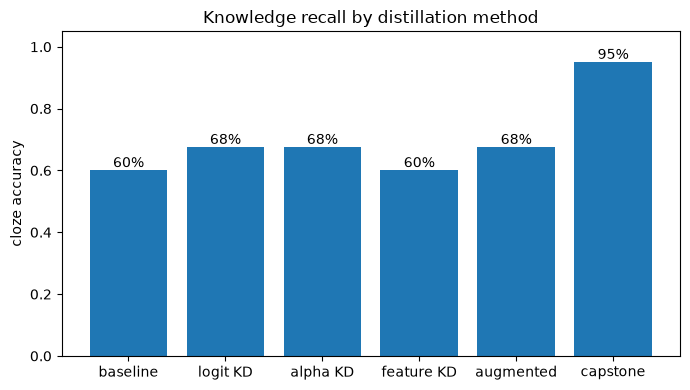

In [2]:
order = [("baseline_hard_label", "baseline"),
         ("logit_kd", "logit KD"),
         ("alpha_kd_best", "alpha KD"),
         ("feature_kd", "feature KD"),
         ("augmented_kd", "augmented"),
         ("capstone", "capstone")]
labels = [lbl for key, lbl in order if key in metrics]
values = [metrics[key] for key, lbl in order if key in metrics]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values)
for b, v in zip(bars, values):
    plt.text(b.get_x() + b.get_width() / 2, v, f"{v:.0%}",
             ha="center", va="bottom")
plt.ylabel("cloze accuracy")
plt.ylim(0, 1.05)
plt.title("Knowledge recall by distillation method")
plt.tight_layout()
plt.savefig("assets/11_summary.png", dpi=120)
print("Saved assets/11_summary.png")

## The numbers

In [3]:
for key, lbl in order:
    if key in metrics:
        print(f"{lbl:12s}: {metrics[key]:.1%}")
if "teacher_params" in metrics and "capstone_params" in metrics:
    ratio = metrics["teacher_params"] / metrics["capstone_params"]
    print(f"\nCapstone student is {ratio:.1f}x smaller than the teacher.")

assert "baseline_hard_label" in metrics and "capstone" in metrics, \
    "recap requires the full metrics file from notebooks 04-10"
print("\nDone. You injected knowledge and distilled it into a smaller model.")

baseline    : 60.0%
logit KD    : 67.5%
alpha KD    : 67.5%
feature KD  : 60.0%
augmented   : 67.5%
capstone    : 95.0%

Capstone student is 12.0x smaller than the teacher.

Done. You injected knowledge and distilled it into a smaller model.
